In [2]:
# Check for GPU (works on Colab, Kaggle, or local with NVIDIA)
# Confirm GPU is connected before proceeding — if this fails, check Runtime > Change runtime type
!nvidia-smi

Sun Sep  6 00:36:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Clone the repo
!git clone https://github.com/lucanest/Phyloformer.git
%cd Phyloformer

Cloning into 'Phyloformer'...
remote: Enumerating objects: 1051, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 1051 (delta 156), reused 149 (delta 149), pack-reused 871 (from 2)
Receiving objects: 100% (1051/1051), 64.58 MiB | 19.35 MiB/s, done.
Resolving deltas: 100% (558/558), done.
/content/Phyloformer/Phyloformer


In [4]:
# The original repo's requirements.txt has broken package names (pytorch should be torch) and a nonexistent pandas version — use this instead
%%writefile requirements_min.txt
biopython
ete3
dendropy
tqdm
numpy
scipy

Writing requirements_min.txt


In [5]:
# legacy-cgi fixes an ete3 import failure specific to Python 3.13+
!pip install -r requirements_min.txt -q
!pip install legacy-cgi -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 113.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.4/465.4 kB 38.3 MB/s eta 0:00:00


In [6]:
# Make binaries executable (Linux/Mac only — skip on Windows)
!chmod +x bin/bin_linux/*

In [7]:
# Two known bugs in the original code: seq2pair (a tensor used internally by the model) doesn't get moved to GPU correctly.
# These two lines fix that — do not skip.
# Fix 1 — phyloformer/model.py
!sed -i 's/device = self.seq2pair.device/device = next(self.parameters()).device/' phyloformer/model.py

# Fix 2 — infer_alns.py
!sed -i '/model = model.to(device)/a\    model.seq2pair = model.seq2pair.to(device)' infer_alns.py

In [11]:
# Shared functions — use these for ALL metric calculations so results are comparable across the team. Do not write your own version of these.
import subprocess
import time
import pandas as pd

def compute_metrics(true_trees_dir, predicted_trees_dir, output_prefix):
    """
    Compares predicted trees against true trees.
    Returns a dataframe with RF, normalized RF, weighted RF, and KF distance per tree.
    """
    subprocess.run([
        "./bin/bin_linux/phylocompare", "-t", "-n",
        "-o", output_prefix,
        true_trees_dir, predicted_trees_dir
    ])
    df = pd.read_csv(f"{output_prefix}_topo.csv")
    return df

def run_fastme(input_matrix_dir, output_tree_dir):
    """
    Converts Phyloformer's distance matrices into trees using FastME.
    """
    import os
    os.makedirs(output_tree_dir, exist_ok=True)
    for file in os.listdir(input_matrix_dir):
        stem = file.split(".")[0]
        subprocess.run([
            "./bin/bin_linux/fastme",
            "-i", f"{input_matrix_dir}/{file}",
            "-o", f"{output_tree_dir}/{stem}.nwk",
            "--nni", "--spr"
        ])

def timed_run(func, *args, **kwargs):
    """
    Wraps any function call and returns (result, elapsed_seconds).
    Use this to record runtime consistently across all methods.
    """
    start = time.time()
    result = func(*args, **kwargs)
    elapsed = time.time() - start
    return result, elapsed

In [20]:
# Shared plotting functions — use these for ALL charts so they match the team's visual style.
# Note: plot_parameter_sweep averages multiple trees per x-value and shows error bars — do not plot raw per-tree values, it creates a misleading zigzag chart.
import matplotlib.pyplot as plt

MODEL_COLORS = {"LG": "#2E86AB", "Cherry": "#F2A93B"}

def plot_parameter_sweep(df, x_col, y_col="kf_score", group_col="model",
                          title="", ylabel="", save_path=None):
    plt.figure(figsize=(7, 5))
    for model, group in df.groupby(group_col):
        summary = group.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
        color = MODEL_COLORS.get(model, "#888888")
        plt.errorbar(summary[x_col], summary["mean"], yerr=summary["std"],
                     marker="o", label=model, color=color, capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(ylabel or y_col)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_runtime(df, x_col, group_col="method", title="Runtime Comparison", save_path=None):
    """
    Runtime chart across methods (Phyloformer, IQ-TREE, FastME, etc.)
    df must have columns: x_col, 'runtime_seconds', group_col
    """
    plt.figure(figsize=(7, 5))
    for method, group in df.groupby(group_col):
        group_sorted = group.sort_values(x_col)
        plt.plot(group_sorted[x_col], group_sorted["runtime_seconds"],
                  marker="o", label=method)
    plt.xlabel(x_col)
    plt.ylabel("Runtime (seconds)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [13]:
# REQUIRED CHECK before doing anything else: run this and confirm the printed KF score is ~0.333.
# If it's not, stop and check your environment setup — do not proceed to your own parameter until this passes.
# First regenerate the toy example predictions
!python infer_alns.py -o data/testdata/pf_matrices models/pf.ckpt data/testdata/msas

import os
os.makedirs("data/testdata/pf_trees", exist_ok=True)
run_fastme("data/testdata/pf_matrices", "data/testdata/pf_trees")

# Now test the metrics function
df = compute_metrics("data/testdata/trees", "data/testdata/pf_trees", "data/test_verify")
print(df["kf_score"].mean())

100% 20/20 [00:05<00:00,  3.93it/s]
0.3329512399083451


WORKED EXAMPLE — this shows the full pipeline on a small 3-size test set (only 10 trees each — too few for real conclusions, this is just to demonstrate the pattern). Copy cells below for your own assigned parameter: replace the simulate_trees.py call with your parameter's values, and increase replicate count for your real run (see the statistical rigor note in Ticket 0.1 — small samples create noisy, unreliable results).

In [17]:
# This is a DEMO run only (10 trees/size) — not enough for a real conclusion.
# Replace tree sizes/counts below with your own parameter and adequate replicate count.
os.makedirs("data/my_test/trees", exist_ok=True)
!python simulate_trees.py -n 10 -t 20 --type birth-death -o data/my_test/trees
!python simulate_trees.py -n 10 -t 50 --type birth-death -o data/my_test/trees
!python simulate_trees.py -n 10 -t 100 --type birth-death -o data/my_test/trees

# NOTE: -i points to the Linux IQ-TREE binary. On Mac, use bin/bin_macos/iqtree_2.2.0 instead.
# On Windows local setups, check if a Windows binary exists in the repo — may need a different approach.
!python alisim.py data/my_test/trees -o data/my_test/alignments -l 300 -g GC -s LG -i bin/bin_linux/iqtree_2.2.0 -p 2

{ 'allow_duplicate_sequences': False,
  'custom_model': None,
  'gamma': 'GC',
  'indels': False,
  'iqtree': 'bin/bin_linux/iqtree_2.2.0',
  'keep_logfiles': False,
  'length': 300,
  'max_attempts': 20,
  'no_summary': False,
  'outdir': 'data/my_test/alignments',
  'processes': 2,
  'substitution': 'LG',
  'trees': 'data/my_test/trees'}
100% 30/30 [00:10<00:00,  2.77it/s]
Failed to simulate 5 alignments without duplicates:
  - data/my_test/trees/6_100_tips.nwk
  - data/my_test/trees/9_100_tips.nwk
  - data/my_test/trees/9_50_tips.nwk
  - data/my_test/trees/7_100_tips.nwk
  - data/my_test/trees/2_100_tips.nwk


In [18]:
os.makedirs("data/my_test/pf_matrices", exist_ok=True)
!python infer_alns.py -o data/my_test/pf_matrices models/pf.ckpt data/my_test/alignments

os.makedirs("data/my_test/pf_trees", exist_ok=True)
run_fastme("data/my_test/pf_matrices", "data/my_test/pf_trees")

df_real = compute_metrics("data/my_test/trees", "data/my_test/pf_trees", "data/my_test_verify")
print(df_real.head())

100% 25/25 [00:19<00:00,  1.30it/s]
          id    rf   norm_rf  weighted_rf  kf_score  n_tips  marker
0  3_50_tips   8.0  0.085106     2.111855  0.402733      50     NaN
1  7_50_tips  12.0  0.127660     0.496080  0.109496      50     NaN
2  1_50_tips  14.0  0.148936     1.882149  0.379519      50     NaN
3  6_20_tips   2.0  0.058824     0.666604  0.228632      20     NaN
4  8_50_tips   6.0  0.063830     1.093885  0.264687      50     NaN


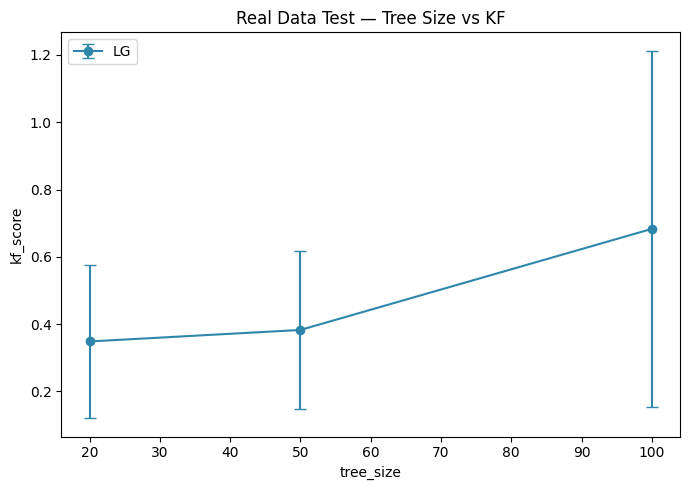

In [21]:
# model="LG" is hardcoded here since this demo only used LG — set this to "Cherry" for Cherry runs
plot_parameter_sweep(
    df_real.rename(columns={"n_tips": "tree_size"}).assign(model="LG"),
    x_col="tree_size", title="Real Data Test — Tree Size vs KF"
)